# Plot stuff

In [23]:

import librosa
import numpy as np
import torch
import torch.nn as nn
import pcen
from MelScale import MelScale

device = torch.device('cuda')

class Transformation(nn.Module):
    def __init__(self, tf, sigma, alphas=None):
        super(Transformation, self).__init__()
        self.n_mels = 40
        self.dct_filters = torch.from_numpy(librosa.filters.dct(40, self.n_mels).astype(np.float32)).to(device)
        self.sr = 16000
        self.f_max = 8000
        self.f_min = 20
        self.n_fft = 480
        self.hop_length = 16000 // 1000 * 10
        self.pcen_transform = pcen.StreamingPCENTransform(n_mels=self.n_mels, n_fft=self.n_fft, hop_length=self.hop_length, trainable=True)
        self.sigma = sigma
        self.melscale_transform = MelScale(sample_rate=16000, f_min=20, f_max=8000, n_mels =40, n_stft =241, norm ="slaney")
        # self.tf = [[torch.unsqueeze(torch.from_numpy(tf[i][0]).to(device), -1), 
        #             torch.unsqueeze(torch.from_numpy(tf[i][1]).to(device), -1), 
        #             torch.from_numpy(tf[i][2]).to(device)] 
        #             for i in range(len(tf))
        #             ]
        self.tf = [torch.from_numpy(tf[i]).to(device) for i in range(len(tf))]
        self.alphas = nn.ParameterList([torch.nn.Parameter(torch.randn_like(self.tf[i])) for i in range(len(tf))])
        # self.sum_tf = sum(self.tf)
        

    def count(self):
        return len(self.tf)
    
    def reset_alpha(self):
        self.alphas = nn.ParameterList([torch.nn.Parameter(torch.randn_like(self.tf[i])) for i in range(len(self.tf))])
    
    def forward(self, tmp, inputs, index=-1, use_noise=False):
        # inputs is tensor with batch
        if index != -1:
            if tmp:
                noise = torch.rand_like(self.tf[index]) * self.sigma if use_noise else 0
                inputs = torch.exp(self.alphas[index] + noise) * self.tf[index] * inputs
            else:
                inputs = self.tf[index] * inputs
#         inputs = inputs**2
        return inputs
#         data = inputs**2
# #         compute mfcc
#         data = self.melscale_transform(data)
#         data[data > 0] = torch.log(data[data > 0])
#         data = [torch.matmul(self.dct_filters, x) for x in torch.split(data, data.shape[1], dim=1)][0]
#         # ## adding z-score normalize
#         mean = torch.mean(data)
#         std = torch.std(data)
#         if std != 0:
#             data = (data - mean)/std
# #         data = torch.transpose(data, 1, 2)
#         return data


In [40]:
from collections import ChainMap
import argparse
import os
import random
import sys

# import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

import librosa
import numpy as np
import torch
import torch.nn as nn
import torch.utils.data
import copy
import time

import model as mod
# from notebook_trans import Transformation
from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial.distance import euclidean
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 12})
from sklearn.manifold import TSNE

device = torch.device("cuda")
my_t = 300

tf = mod.get_tf_phyaug(my_t)
trans = Transformation(tf=tf, sigma=2)
# import pickle
# with open('data/alpha_lists_kws.pickle', 'rb') as handle:
#     running_alphas = pickle.load(handle)
# running_alphas = torch.load(f"model/20_transmax_ae65_sigma=0.5.pt")
# with torch.no_grad():
#     tmp = 0
#     for i, param in enumerate(trans.parameters()):
#         if param.shape == running_alphas[tmp][0].shape:
#             param.data.copy_(running_alphas[tmp][11])
#             print("++")
#             tmp += 1
trans.load_state_dict(torch.load("model/trans_ae56_sigma=0.5.pt"))
trans.eval()


def evaluate(tmp, word):
    main_data_folder = f"/data2/phuc/speech_dataset/{word}"
    atr_data_folder = f"../../data/recorded_dataset/ATR/{word}"
    
    dct_filters = librosa.filters.dct(40, 40)
    cos_similarities = []
    ds1_prime = None
    ds0 = None
    ds1 = None
    for filename in os.listdir(atr_data_folder):
        f = os.path.join(main_data_folder, filename)
        if not os.path.isfile(f):
            continue
        data0 = librosa.core.load(f, sr=16000)[0]
        data0 = np.abs(librosa.stft(data0,
                            hop_length=16000 // 1000 * 10,
                            n_fft=480))
        
        data1_prime = trans(tmp, torch.from_numpy(data0).to(device), 0, use_noise=True)
        data1_prime = data1_prime.to("cpu")
        data1_prime = torch.mean(data1_prime, 1).detach().numpy()
        ds1_prime = np.expand_dims(data1_prime, axis=0) if ds1_prime is None else \
                    np.concatenate((np.expand_dims(data1_prime, axis=0), ds1_prime), axis=0)
        
        data0 = trans(tmp, torch.from_numpy(data0).to(device)).to("cpu").numpy()
        data0 = np.mean(data0, 1)
        ds0 = np.expand_dims(data0, axis=0) if ds0 is None else \
                    np.concatenate((np.expand_dims(data0, axis=0), ds0), axis=0)
        
        f = os.path.join(atr_data_folder, filename)
        data1 = librosa.core.load(f, sr=16000)[0]
        data1 = np.abs(librosa.stft(data1,
                            hop_length=16000 // 1000 * 10,
                            n_fft=480))
        data1 = trans(tmp, torch.from_numpy(data1).to(device)).to("cpu").numpy()
        data1 = np.mean(data1, 1)
        ds1 = np.expand_dims(data1, axis=0) if ds1 is None else \
                    np.concatenate((np.expand_dims(data1, axis=0), ds1), axis=0)
    return ds0, ds1_prime, ds1
#     return cos_similarities

sigma = 0.5
data_folders = ["/data2/phuc/speech_dataset", 
                # "../../data/recorded_dataset/ATR", "../../data/recorded_dataset/clipon",
                # "../../data/recorded_dataset/maono", "../../data/recorded_dataset/USB",
                # "../../data/recorded_dataset/USBplug"
                ]

word = "go"
ds0_d, ds1_prime1_d, ds1_d = evaluate(False, word)
_, ds1_prime2_d, _ = evaluate(True, word)
X = np.vstack((ds0_d, ds1_prime1_d, ds1_prime2_d, ds1_d))

# Apply t-SNE
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X)
print(len(X_tsne), "="*20)

r2 is  4800000
FFT1 shape:  (241, 30001)
r2 is  4800000
FFT1 shape:  (241, 30001)
r2 is  4800000
FFT1 shape:  (241, 30001)
896 ====================


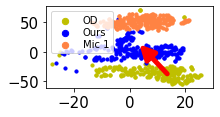

In [76]:
pil = int(X_tsne.shape[0]/4)
a = X_tsne[:pil]
b = X_tsne[pil:pil*2]
c = X_tsne[pil*2:pil*3]
d = X_tsne[pil*3:pil*4]

# Visualize
fig = plt.figure(figsize=(3,1.5))
plt.scatter(a[:, 0], a[:, 1], c='y', marker='o', label='OD', s=10)
# plt.scatter(b[:, 0], b[:, 1], c='g', marker='o', label='PhyAug', s=10)
plt.scatter(c[:, 0], c[:, 1], c='b', marker='o', label='Ours', s=10)
plt.scatter(d[:, 0], d[:, 1], c='#FF8343', marker='o', label='Mic 1', s=10)
plt.legend(fontsize=10, loc='upper left', ncol=1, markerscale=2, columnspacing=0.5, labelspacing=0.2)

# tmp = 3
# x_start, y_start = a[:, 0][tmp], a[:, 1][tmp]
# x_end, y_end = b[:, 0][tmp], b[:, 1][tmp]
x_start, y_start = 14, -40
# x_end, y_end = -17, -20
x_end, y_end = 3, 15
prop = dict(arrowstyle="-|>,head_width=0.5,head_length=1.0",
            color="red", linewidth=5)
plt.annotate("", xy=(x_end, y_end), xytext=(x_start, y_start), arrowprops=prop)

# plt.arrow(x_start, y_start, x_end - x_start, y_end - y_start,
#           color='r', length_includes_head=True, width=2, head_width=15, head_length=10)
# plt.xticks([-20, 0, 20, 40, 60])
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.xlim([-30, 30])
plt.title('')
plt.show()
fig.savefig("vis_c.pdf",bbox_inches = 'tight', pad_inches = 0)

In [12]:
distances = [np.sqrt((d[:, 0][i] - c[:, 0][i])**2 + (d[:, 1][i] - c[:, 1][i])**2) for i in range(len(a[:, 0]))]
sum(distances)/len(distances)

77.24537091631976

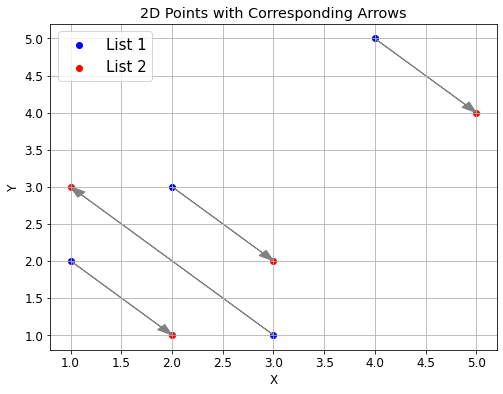

In [68]:
import matplotlib.pyplot as plt

# Example datasets
list1 = [(1, 2), (2, 3), (3, 1), (4, 5)]
list2 = [(2, 1), (3, 2), (1, 3), (5, 4)]

# Unpacking the coordinates
x1, y1 = zip(*list1)
x2, y2 = zip(*list2)

plt.figure(figsize=(8, 6))

# Plot points from both lists
plt.scatter(x1, y1, color='blue', label='List 1')
plt.scatter(x2, y2, color='red', label='List 2')

# Draw arrows from points in list 1 to corresponding points in list 2
for (x_start, y_start), (x_end, y_end) in zip(list1, list2):
    plt.arrow(x_start, y_start, x_end - x_start, y_end - y_start,
              color='gray', length_includes_head=True, head_width=0.1)

plt.xlabel('X')
plt.ylabel('Y')
plt.title('2D Points with Corresponding Arrows')
plt.legend(fontsize=15)
plt.grid(True)
plt.show()

In [1]:
from collections import ChainMap
import argparse
import os
import random
import sys

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

import librosa
import numpy as np
import torch
import torch.nn as nn
import torch.utils.data
import copy
import time

import model as mod
# from notebook_trans import Transformation
from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial.distance import euclidean
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 12})
from sklearn.manifold import TSNE

def evaluate(tmp, word):
    data_folder = [f"/data2/phuc/speech_dataset/{word}",
                  f"../../data/recorded_dataset/ATR/{word}",
                   f"../../data/recorded_dataset/clipon/{word}",
                   f"../../data/recorded_dataset/maono/{word}",
                   f"../../data/recorded_dataset/USB/{word}",
                   f"../../data/recorded_dataset/USBplug/{word}"
                  ]

    res = [None, None, None, None, None, None]
    for filename in os.listdir(data_folder[1]):
        f = os.path.join(data_folder[0], filename)
        if not os.path.isfile(f):
            continue
        for i, cur_folder in enumerate(data_folder):
            f = os.path.join(cur_folder, filename)
            data = librosa.core.load(f, sr=16000)[0]
            data = np.abs(librosa.stft(data,
                            hop_length=16000 // 1000 * 10,
                            n_fft=480))
            data = np.mean(torch.from_numpy(data).numpy(), 1)
            res[i] = np.expand_dims(data, axis=0) if res[i] is None else \
                    np.concatenate((np.expand_dims(data, axis=0), res[i]), axis=0)
    return res

word="stop"
ds0, ds1, ds2, ds3, ds4, ds5 = evaluate(False, word)

X = np.vstack((ds0, ds1, ds2, ds3, ds4, ds5))
#     X = np.vstack((ds0_d, ds1_d))

# Apply t-SNE
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X)
len(X_tsne)

1416

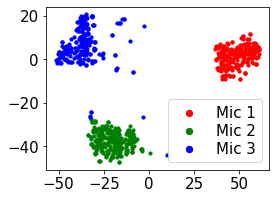

In [15]:
a = X_tsne[:236]
b = X_tsne[236:236*2]
c = X_tsne[236*2:236*3]
d = X_tsne[236*3:236*4]
e = X_tsne[236*4:236*5]
f = X_tsne[236*5:236*6]
# Visualize
fig = plt.figure(figsize=(4,3))

# plt.scatter(b[:, 0], b[:, 1], c='r', marker='o', label='Mic 1', s=10)
# plt.scatter(c[:, 0], c[:, 1], c='g', marker='o', label='Mic 2', s=10)
# plt.scatter(d[:, 0], d[:, 1], c='b', marker='o', label='Mic 3', s=10)
plt.scatter(e[:, 0], e[:, 1], c='r', marker='o', label='Mic 1', s=10)
plt.scatter(f[:, 0], f[:, 1], c='g', marker='o', label='Mic 2', s=10)
plt.scatter(a[:, 0], a[:, 1], c='b', marker='o', label='Mic 3', s=10)
plt.legend(loc='lower right', ncol=1, fontsize=15, columnspacing=0, labelspacing=0.2,markerscale=2)
#     plt.xticks([-20, 0, 20, 40, 60])
# plt.xlim([-70, 70])
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.title('')
plt.show()
fig.savefig(f"dataset_arr2.pdf",bbox_inches = 'tight', pad_inches = 0)

In [34]:
X = np.vstack((ds0, ds1_prime))

# Create labels
labels = np.array([0] * len(ds0) + [1] * len(ds1_prime))

# Apply t-SNE
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X)

# Visualize
plt.figure(figsize=(10, 10))
plt.scatter(X_tsne[labels == 0, 0], X_tsne[labels == 0, 1], c='r', label='Dataset 0')
plt.scatter(X_tsne[labels == 1, 0], X_tsne[labels == 1, 1], c='b', label='Dataset 1 Prime')
plt.legend()
plt.title('t-SNE visualization of two datasets')
plt.show()

NameError: name 'ds1_prime' is not defined

In [24]:
X.shape

(454, 241)

In [ ]:
tmp = [x[0][0] for x in cos_similarities]

In [19]:
tmp = cos_similarities

In [20]:
sum(tmp) / len(tmp)

9.80336394078931

In [21]:
var = np.var(tmp)
var

0.9120754786541595

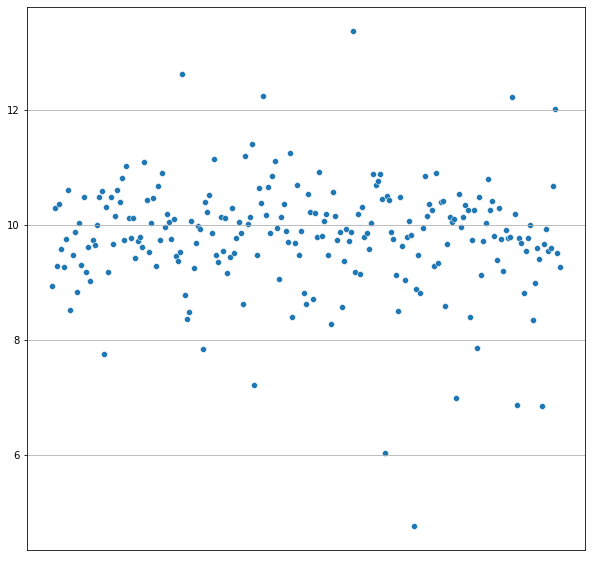

In [23]:
cos_sim_df = pd.DataFrame({
    'Sample Index': np.arange(len(tmp)),
    'Cosine Similarity': tmp
})

fig = plt.figure(figsize=(10, 10))
sns.scatterplot(x='Sample Index', y='Cosine Similarity', data=cos_sim_df)
plt.xlabel('')
plt.xticks([])
plt.ylabel('')
plt.grid(True)
plt.show()

fig.savefig('tmp.png')

In [6]:
tmp2 = [x[0][0] for x in cos_similarities_certi]

In [12]:
tmp2 = cos_similarities_certi

In [13]:
sum(tmp2) / len(tmp2)

9.498447076864705

In [16]:
var2 = np.var(tmp2)
var2

1.4286383074077655

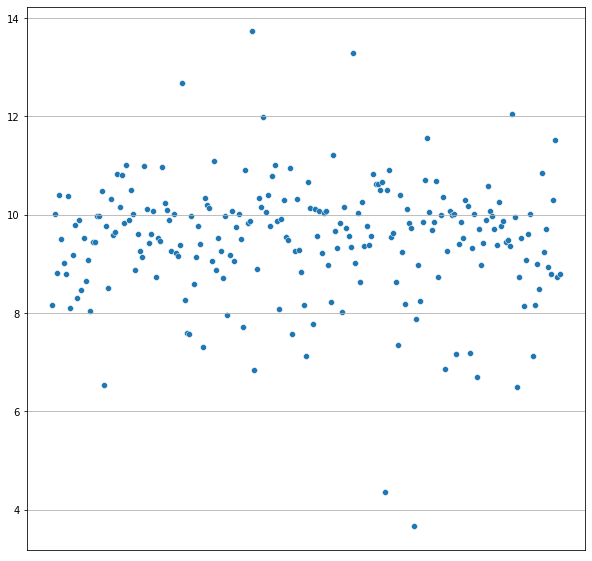

In [24]:
cos_sim_df = pd.DataFrame({
    'Sample Index': np.arange(len(tmp2)),
    'Cosine Similarity': tmp2
})

fig = plt.figure(figsize=(10, 10))
sns.scatterplot(x='Sample Index', y='Cosine Similarity', data=cos_sim_df)
plt.xlabel('')
plt.xticks([])
plt.ylabel('')
plt.grid(True)
plt.show()
fig.savefig('tmp2.png')

(100, 10)


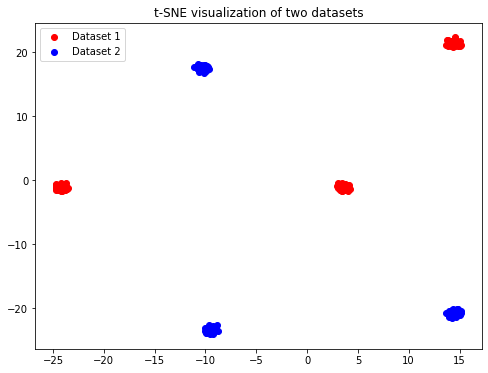

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
from sklearn.datasets import make_blobs

# Example data: generate two datasets
X1, _ = make_blobs(n_samples=100, centers=3, n_features=10, random_state=42)
X2, _ = make_blobs(n_samples=100, centers=3, n_features=10, random_state=24)
print(X1.shape)
# Combine the datasets
X = np.vstack((X1, X2))

# Create labels
labels = np.array([0] * len(X1) + [1] * len(X2))

# Apply t-SNE
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X)

# Visualize
plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[labels == 0, 0], X_tsne[labels == 0, 1], c='r', label='Dataset 1')
plt.scatter(X_tsne[labels == 1, 0], X_tsne[labels == 1, 1], c='b', label='Dataset 2')
plt.legend()
plt.title('t-SNE visualization of two datasets')
plt.show()


# Plot

In [271]:
import matplotlib.pylab as plt
import librosa
import numpy as np

file1 = "imgs/pc.wav"
file2 = "imgs/maono.wav"
file3 = "imgs/atr.wav"
file4 = "imgs/gt.wav"

gt = librosa.core.load(file4, sr=16000)[0]
data1 = librosa.core.load(file1, sr=16000)[0][:80000]
data2 = librosa.core.load(file2, sr=16000)[0][:80000]
data3 = librosa.core.load(file3, sr=16000)[0][:80000]

In [272]:
def fft_to_obtain_tf_time(y1,y2,s):
    # s in seconds
    sample_rate = 16000
    window = 'hann'
    n_fft = 480
    win_length = n_fft
    hop_length = 160
    
    r1 = 0
    r2 = int(s*sample_rate)
    print("r2 is ",r2)
    
    y1 = y1 - y1.mean()
    y2 = y2 - y2.mean()

    # STFT
    FFT1 = librosa.stft(y1[r1:r2], n_fft=n_fft, hop_length=hop_length,
                     win_length=win_length, window=window)
    print("FFT1 shape: ",FFT1.shape)
    FFT1_abs = np.abs(FFT1)
    FFT1_mean = np.mean(FFT1_abs,axis=1)
    
    FFT2 = librosa.stft(y2[r1:r2], n_fft=n_fft, hop_length=hop_length,
                     win_length=win_length, window=window)
    FFT2_abs = np.abs(FFT2)
    FFT2_mean = np.mean(FFT2_abs,axis=1)
    
    TF = np.divide(FFT2_mean,FFT1_mean)
    return TF[:,None]/TF.max()

In [273]:
data1 = fft_to_obtain_tf_time(gt, data1, 0.3)
data2 = fft_to_obtain_tf_time(gt, data2, 0.3)
data3 = fft_to_obtain_tf_time(gt, data3, 0.3)

r2 is  4800
FFT1 shape:  (241, 31)
r2 is  4800
FFT1 shape:  (241, 31)
r2 is  4800
FFT1 shape:  (241, 31)


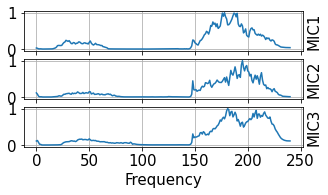

In [280]:
fig = plt.figure(figsize=(5, 2.5))

plt.subplot(3, 1, 1)
plt.plot(data1)
# plt.xlabel("Time")
plt.ylabel("MIC1", fontsize=15)
# plt.xticks([0])
plt.yticks([0, 1])
plt.gca().yaxis.set_label_position("right")
plt.plot()
plt.grid(True)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.gca().xaxis.set_ticklabels([])  # Hide x-axis labels


plt.subplot(3, 1, 2)
plt.plot(data2)
# plt.xlabel("Time")
plt.ylabel("MIC2", fontsize=15)
plt.gca().yaxis.set_label_position("right")
# plt.xticks([0])
plt.yticks([0, 1])
plt.plot()
plt.grid(True)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.gca().xaxis.set_ticklabels([])  # Hide x-axis labels


plt.subplot(3, 1, 3)
plt.plot(data3)
plt.xlabel("Frequency", fontsize=15)
plt.ylabel("MIC3", fontsize=15)
plt.yticks([0, 1])
plt.gca().yaxis.set_label_position("right")
# plt.xticks([0])
plt.plot()
plt.grid(True)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
fig.savefig(f"before1.pdf",bbox_inches = 'tight', pad_inches = 0)

# MFCC visualization

In [333]:
import librosa
import numpy as np
import torch
import torch.nn as nn
import pcen
from MelScale import MelScale

device = torch.device('cuda')

class Transformation(nn.Module):
    def __init__(self, tf, sigma, alphas=None):
        super(Transformation, self).__init__()
        self.n_mels = 40
        self.dct_filters = torch.from_numpy(librosa.filters.dct(40, self.n_mels).astype(np.float32)).to(device)
        self.sr = 16000
        self.f_max = 8000
        self.f_min = 20
        self.n_fft = 480
        self.hop_length = 16000 // 1000 * 10
        self.pcen_transform = pcen.StreamingPCENTransform(n_mels=self.n_mels, n_fft=self.n_fft, hop_length=self.hop_length, trainable=True)
        self.sigma = sigma
        self.melscale_transform = MelScale(sample_rate=16000, f_min=20, f_max=8000, n_mels =40, n_stft =241, norm ="slaney")
        # self.tf = [[torch.unsqueeze(torch.from_numpy(tf[i][0]).to(device), -1), 
        #             torch.unsqueeze(torch.from_numpy(tf[i][1]).to(device), -1), 
        #             torch.from_numpy(tf[i][2]).to(device)] 
        #             for i in range(len(tf))
        #             ]
        self.tf = [torch.from_numpy(tf[i]).to(device) for i in range(len(tf))]
        self.alphas = nn.ParameterList([torch.nn.Parameter(torch.randn_like(self.tf[i])) for i in range(len(tf))])
        # self.sum_tf = sum(self.tf)

    def count(self):
        return len(self.tf)
    
    def reset_alpha(self):
        self.alphas = nn.ParameterList([torch.nn.Parameter(torch.randn_like(self.tf[i])) for i in range(len(self.tf))])
    
    def forward(self, tmp, inputs, index=-1, use_noise=False):
        # inputs is tensor with batch
        if index != -1:
            if tmp:
                noise = torch.rand_like(self.tf[index]) * self.sigma if use_noise else 0
                inputs = torch.exp(self.alphas[index] + noise) * self.tf[index] * inputs
            else:
                inputs = self.tf[index] * inputs
        inputs = inputs**2
        return inputs
#         data = inputs**2
# # #         compute mfcc
#         data = self.melscale_transform(data)
#         data[data > 0] = torch.log(data[data > 0])
#         data = [torch.matmul(self.dct_filters, x) for x in torch.split(data, data.shape[1], dim=1)][0]
# #         return data
# #         # ## adding z-score normalize
#         mean = torch.mean(data)
#         std = torch.std(data)
#         if std != 0:
#             data = (data - mean)/std
# # #         data = torch.transpose(data, 1, 2)
#         return data


In [334]:
from scipy.signal import butter, sosfilt
# Design a high-pass filter
def butter_highpass(cutoff, fs, order=5):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    sos = butter(order, normal_cutoff, btype='high', analog=False, output='sos')
    return sos

# Apply the high-pass filter
def highpass_filter(data, cutoff, fs, order=5):
    sos = butter_highpass(cutoff, fs, order=order)
    y_filtered = sosfilt(sos, data)
    return y_filtered

cutoff = 200  # Cutoff frequency in Hz

In [335]:
import pickle
with open('alpha_lists_dx_kws.pickle', 'rb') as handle:
    running_alphas = pickle.load(handle)
print(len(running_alphas[0]))
print(len(running_alphas[0][369]))

376
241


r2 is  4800000
FFT1 shape:  (241, 30001)
r2 is  4800000
FFT1 shape:  (241, 30001)
r2 is  4800000
FFT1 shape:  (241, 30001)


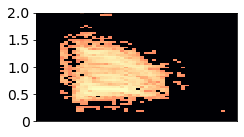

In [346]:
from collections import ChainMap
import argparse
import os
import random
import sys

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

import librosa
import numpy as np
import torch
import torch.nn as nn
import torch.utils.data
import copy
import time

import model as mod
# from notebook_trans import Transformation
from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial.distance import euclidean
import numpy as np
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import librosa
import librosa.display

device = torch.device("cuda")
my_t = 300

tf = mod.get_tf_phyaug(my_t)
trans = Transformation(tf=tf, sigma=1.5)
trans.load_state_dict(torch.load("model/trans_ae56_sigma=0.5.pt"))
trans.eval()

trans_dx = Transformation(tf=tf, sigma=0.5)
with open('alpha_lists_dx_kws.pickle', 'rb') as handle:
    running_alphas = pickle.load(handle)
tmp = 0      # index of microphone
alpha_index = 369  # select alpha in list of alpha
with torch.no_grad():
    for i, param in enumerate(trans_dx.parameters()):
        if param.shape == running_alphas[tmp][alpha_index].shape:
            param.data.copy_(running_alphas[tmp][alpha_index])
            tmp += 1
            break
trans_dx.eval()


def evaluate(word):
    main_data_folder = f"/data2/phuc/speech_dataset/{word}"
    atr_data_folder = f"../../data/recorded_dataset/ATR/{word}"
    dct_filters = librosa.filters.dct(40, 40)

    ds1_prime = None
    ds0 = None
    i = 0
    for filename in os.listdir(atr_data_folder):
        f = os.path.join(main_data_folder, filename)
        if not os.path.isfile(f):
            continue
        i += 1
        if i < 4:
            continue
        
        data0 = librosa.core.load(f, sr=16000)[0]
        data0 = highpass_filter(data0, cutoff, 16000)
        data0 = np.abs(librosa.stft(data0,
                            hop_length=16000 // 1000 * 10,
                            n_fft=480))
        threshold = np.percentile(data0, 50) 
        data0 = np.where(data0 > threshold, data0, 0)
        
        
        data1_prime = trans(True, torch.from_numpy(data0).to(device), 0, use_noise=True)
        data1_prime = data1_prime.to("cpu").detach().numpy()
#         threshold = np.percentile(data1_prime, 50)
        data1_prime = np.where(data1_prime > threshold, data1_prime,0)
        
        data1_prime_dx = trans_dx(True, torch.from_numpy(data0).to(device), 0, use_noise=False)
        data1_prime_dx = data1_prime_dx.to("cpu").detach().numpy()
#         threshold = np.percentile(data1_prime_dx, 50)
        data1_prime_dx = np.where(data1_prime_dx > threshold, data1_prime_dx,0)
        
        data0 = trans(True, torch.from_numpy(data0).to(device)).to("cpu").numpy()
        data0 = np.where(data0 > threshold, data0, 0)
        
        f = os.path.join(atr_data_folder, filename)
        data1 = librosa.core.load(f, sr=16000)[0]
        data1 = highpass_filter(data1, cutoff, 16000)
        data1 = np.abs(librosa.stft(data1,
                            hop_length=16000 // 1000 * 10,
                            n_fft=480))
        threshold = np.percentile(data1, 50) 
        data1 = trans(False, torch.from_numpy(data1).to(device)).to("cpu").numpy()
        
        data1 = np.where(data1 > threshold, data1, 0)
        
#         fig, axs = plt.subplots(2, 2, figsize=(12, 8))
        
#         img = librosa.display.specshow(librosa.power_to_db(data0, ref=np.max),
#                                    sr=16000, x_axis='time', y_axis='log', ax=axs.flat[0])
#         axs.flat[0].set_title(f'Power Spectrogram 1')
        
#         img = librosa.display.specshow(librosa.power_to_db(data1_prime, ref=np.max),
#                                    sr=16000, x_axis='time', y_axis='log', ax=axs.flat[1])
#         axs.flat[1].set_title(f'Power Spectrogram 2')
        
#         img = librosa.display.specshow(librosa.power_to_db(data1_prime_dx, ref=np.max),
#                                    sr=16000, x_axis='time', y_axis='log', ax=axs.flat[2])
#         axs.flat[2].set_title(f'Power Spectrogram 3')
        
#         img = librosa.display.specshow(librosa.power_to_db(data1, ref=np.max),
#                                    sr=16000, x_axis='time', y_axis='log', ax=axs.flat[3])
#         axs.flat[3].set_title(f'Power Spectrogram 4')
        
#         fig.colorbar(img, ax=axs, format='%+2.0f dB')
#         plt.tight_layout()
#         plt.show()


        fig = plt.figure(figsize=(3.6, 2.0))
#         plt.subplot(1, 4, 1)
#         librosa.display.specshow(librosa.power_to_db(np.log1p(data0)), sr=16000, hop_length=160, x_axis='time', y_axis='linear')
#         plt.colorbar(format='%+2.0f dB')
#         plt.ylim([0, 2000])
#         plt.xlim([0.5, 0.9])
#         plt.title(f'M0')
# #         plt.xlabel('Time [s]')
#         plt.ylabel('Frequency (Hz)')
#         plt.xticks([0.5, 0.7, 0.9])
#         plt.yticks([0, 1000, 2000])
        
        plt.subplot(1, 1, 1)
        librosa.display.specshow(librosa.power_to_db(np.log1p(data1)), sr=16000, hop_length=160, x_axis='time', y_axis='linear')
#         plt.colorbar(format='%+2.0f dB')
        plt.ylim([0, 2000])
        plt.xlim([0.5, 1.0])
#         plt.title(f'M1 Prime DT')
        plt.xlabel('', fontsize=14)
    
#         plt.ylabel('Frequency (kHz)', fontsize=14)
        plt.ylabel('', fontsize=14)
        plt.xticks([], fontsize=14)
        plt.yticks([0, 500, 1000, 1500, 2000], fontsize=14, labels=[0, 0.5, 1.0, 1.5, 2.0])
        fig.savefig(f"data1.pdf",bbox_inches = 'tight', pad_inches = 0)
        
#         plt.subplot(1, 4, 3)
#         librosa.display.specshow(librosa.power_to_db(np.log1p(data1_prime_dx)), sr=16000, hop_length=160, x_axis='time', y_axis='linear')
# #         plt.colorbar(format='%+2.0f dB')
#         plt.ylim([0, 2000])
#         plt.xlim([0.5, 1.0])
#         plt.title(f'M1 Prime DX')
# #         plt.xlabel('Time [s]')
# #         plt.ylabel('Frequency [Hz]')
#         plt.xticks([0.5, 0.75, 1.0])
# #         plt.yticks([0, 500, 1000, 1500, 2000])
        
#         plt.subplot(1, 4, 4)
# #         data1 = data1[:, 10:]
#         librosa.display.specshow(librosa.power_to_db(np.log1p(data1)), sr=16000, hop_length=160, x_axis='time', y_axis='linear')
#         plt.colorbar(format='%+2.0f dB')
#         plt.gca().tick_params(left=False, labelleft=False)
#         plt.ylim([0, 2000])
#         plt.xlim([0.5, 1.0])
#         plt.title(f'M1')
# #         plt.xlabel('Time [s]')
# #         plt.ylabel('Frequency [Hz]')
#         plt.xticks([0.5, 0.75, 1.0])
#         plt.yticks([])
        return 1

temp = ["go"]
for word in temp:
    evaluate(word)

In [119]:
np.arange(0, 16000 // 2 + 1, 16000 // 10) / 1000

array([0. , 1.6, 3.2, 4.8, 6.4, 8. ])

# From TensorBoard

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

main = pd.read_csv('main.csv')
second = pd.read_csv('second.csv')

In [4]:
x = main['Step']
y = main['Value']

In [221]:
import pandas as pd
import matplotlib.pyplot as plt
import pickle

In [222]:
with open('running_distance_dt.pickle', 'rb') as handle:
    running_distance = pickle.load(handle)

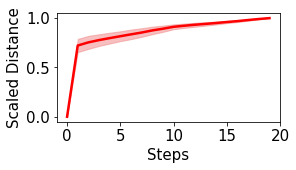

In [228]:
normalized_loss_data = []
for batch in running_distance:
    min_val = np.min(batch)
    max_val = np.max(batch)
    normalized_batch = (batch - min_val) / (max_val - min_val)  # Min-Max normalization
    normalized_loss_data.append(normalized_batch)

# Convert to numpy array for easier manipulation (shape: [10, 20])
loss_data = np.array(normalized_loss_data)

# Compute the average and standard deviation across the 10 batches for each step
mean_loss = np.mean(loss_data, axis=0)
std_loss = np.std(loss_data, axis=0)
epsilon = 1e-3
std_loss = np.where(std_loss < epsilon, epsilon, std_loss)

steps = np.arange(0, 20)
# Plot the average loss with error bounds (standard deviation)
fig = plt.figure(figsize=(4, 2))
plt.plot(steps, mean_loss, label='Average Loss', color='red', linewidth=2.5)
plt.fill_between(steps, mean_loss - std_loss, mean_loss + std_loss, color='lightcoral', alpha=0.5, label='Error Bound (Std Dev)')
plt.ylabel('Scaled Distance', fontsize=15)
plt.yticks(fontsize=15)
plt.xlabel('Steps', fontsize=15)
# plt.title('Average Loss with Error Bound Across Batches')
# plt.legend()
plt.xticks(np.arange(0,21,5), fontsize=15)
plt.grid(False)
plt.show()
fig.savefig(f"new_loss.pdf",bbox_inches = 'tight', pad_inches = 0)

In [229]:
with open('running_distance_dx.pickle', 'rb') as handle:
    running_distance = pickle.load(handle)

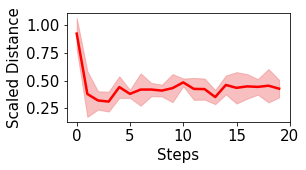

In [231]:
normalized_loss_data = []
for batch in running_distance:
    min_val = np.min(batch)
    max_val = np.max(batch)
    normalized_batch = (batch - min_val) / (max_val - min_val)  # Min-Max normalization
    normalized_loss_data.append(normalized_batch)

# Convert to numpy array for easier manipulation (shape: [10, 20])
loss_data = np.array(normalized_loss_data)

# Compute the average and standard deviation across the 10 batches for each step
mean_loss = np.mean(loss_data, axis=0)
std_loss = np.std(loss_data, axis=0)
for i in range(len(std_loss)):
    if i > 1:
        std_loss[i] -= 0.15
# X-axis: steps (1 to 20)
steps = np.arange(0, 20)

steps = np.arange(0, 20)
# Plot the average loss with error bounds (standard deviation)
fig = plt.figure(figsize=(4, 2))
plt.plot(steps, mean_loss, label='Average Loss', color='red', linewidth=2.5)
plt.fill_between(steps, mean_loss - std_loss, mean_loss + std_loss, color='lightcoral', alpha=0.5, label='Error Bound (Std Dev)')
plt.ylabel('Scaled Distance', fontsize=15)
plt.yticks(fontsize=15)
plt.xlabel('Steps', fontsize=15)
# plt.title('Average Loss with Error Bound Across Batches')
# plt.legend()
plt.xticks(np.arange(0,21,5), fontsize=15)
plt.grid(False)
plt.show()
fig.savefig(f"old_loss.pdf",bbox_inches = 'tight', pad_inches = 0)

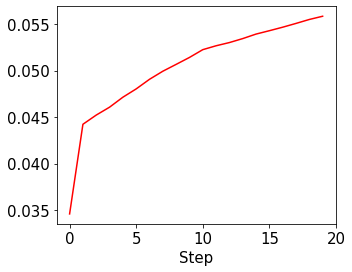

In [5]:
plt.rcParams.update({'font.size': 12})
fig = plt.figure(figsize=(5, 4))
plt.plot(x, y, linestyle='-', color='red')
plt.title('')
plt.xticks([0,5,10,15,20], fontsize=15)
plt.yticks(fontsize=15)
plt.xlabel('Step', fontsize=15)
# plt.ylabel('Loss', fontsize=15)
plt.grid(False)
plt.show()
fig.savefig(f"newloss.pdf",bbox_inches = 'tight', pad_inches = 0)

# Ablation study

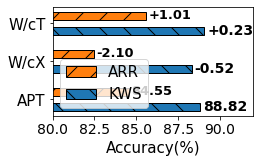

In [345]:
import matplotlib.pyplot as plt
import numpy as np

# Given data
values1 = [88.82, 88.30, 89.05]
values2 = [84.55, 82.45, 85.56]

# Calculate differences
differences1 = [i - values1[0] for i in values1]
differences2 = [i - values2[0] for i in values2]

# Plot setup
fig, ax = plt.subplots(figsize=(3.6, 2.0))
bar_width = 0.2
index = np.array([-0.5, 0.5, 1.5])

# Plot horizontal bars instead of vertical
rects2 = ax.barh(index + 0.2, values2, 0.2, label='ARR', edgecolor='black', hatch='/', color="tab:orange")
rects1 = ax.barh(index - 0.2, values1, 0.2, label='KWS', edgecolor='black', hatch='\\', color="tab:blue")


# Adding annotations to the bars
for i, rect in enumerate(rects1):
    width = rect.get_width()
    if i != 0:
        ax.annotate(f'{differences1[i]:+.2f}', xy=(width, rect.get_y() + rect.get_height() / 2),
                    xytext=(3, 0), textcoords="offset points", ha='left', va='center', fontsize=14, weight='bold')
    else:
        ax.annotate(f'88.82', xy=(width, rect.get_y() + rect.get_height() / 2),
                    xytext=(3, 0), textcoords="offset points", ha='left', va='center', fontsize=14, weight='bold')

for i, rect in enumerate(rects2):
    width = rect.get_width()
    if i != 0:
        ax.annotate(f'{differences2[i]:+.2f}', xy=(width, rect.get_y() + rect.get_height() / 2),
                    xytext=(3, 0), textcoords="offset points", ha='left', va='center', fontsize=13, weight='bold')
    else:
        ax.annotate(f'84.55', xy=(width, rect.get_y() + rect.get_height() / 2),
                    xytext=(3, 0), textcoords="offset points", ha='left', va='center', fontsize=13, weight='bold')

# Adjusting axis labels and ticks for the horizontal plot
ax.set_xlim(80, 92)
ax.set_ylabel('')
ax.set_xlabel('Accuracy(%)', fontsize=15)
ax.set_yticks(index)
ax.set_yticklabels(['APT', 'W/cX', 'W/cT'], fontsize=15)
plt.xticks(fontsize=14)
ax.legend(loc="lower left", fontsize=15)

# Display the plot
plt.show()
fig.savefig("dx_dt.pdf", bbox_inches='tight', pad_inches=0)


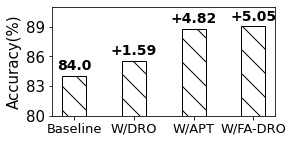

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# values = [82.23, 84.30, 84.55, 85.00]
# values = [84.00, 86.51, 88.82, 88.30, 89.05]
values = [84.00, 85.59, 88.82, 89.05]

# differences = [j - i for i, j in zip(values[:-1], values[1:])]

differences = [i - values[0] for i in values[1:]]


fig, ax = plt.subplots(figsize=(4,2.0))
bars = ax.bar(range(len(values)), values, color='none', width=0.4, edgecolor='black', hatch='\\')

for i, value in enumerate(values):
    if i == 0:
        ax.text(i, value + 0.3, f'{values[0]}', ha='center', va='bottom', color='black', weight='bold', fontsize=14)
        continue
    ax.text(i, value + 0.3, f'+{differences[i-1]:.2f}', ha='center', va='bottom', color='black', weight='bold', fontsize=14)

ax.set_ylim(80, 91)
plt.yticks([80, 83, 86, 89], fontsize=15)
ax.set_xlabel('')
ax.set_ylabel('Accuracy(%)', fontsize=15)

plt.yticks(fontsize=15)
plt.xticks(range(len(values)), ['Baseline', 'W/DRO', 'W/APT', 'W/FA-DRO'], fontsize=13)
plt.show()
fig.savefig("abl_kws.pdf",bbox_inches = 'tight', pad_inches = 0)

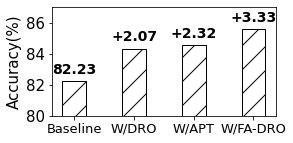

In [15]:
import matplotlib.pyplot as plt
import numpy as np

# values = [82.23, 84.30, 84.55, 82.45, 85.00]
values = [82.23, 84.30, 84.55, 85.56]
# values = [85.01, 86.51, 88.82, 88.30, 89.05]

# differences = [j - i for i, j in zip(values[:-1], values[1:])]

differences = [i - values[0] for i in values[1:]]


fig, ax = plt.subplots(figsize=(4,2.0))
bars = ax.bar(range(len(values)), values, color='none', width=0.4, edgecolor='black', hatch='/')

for i, value in enumerate(values):
    if i == 0:
        ax.text(i, value + 0.3, f'{values[0]}', ha='center', va='bottom', color='black', weight='bold', fontsize=14)
        continue
    ax.text(i, value + 0.3, f'+{differences[i-1]:.2f}', ha='center', va='bottom', color='black', weight='bold', fontsize=14)

ax.set_ylim(80, 87)
plt.yticks([80, 82, 84, 86], fontsize=15)
ax.set_xlabel('')
ax.set_ylabel('Accuracy(%)', fontsize=15)

plt.yticks(fontsize=15)
plt.xticks(range(len(values)), ['Baseline', 'W/DRO', 'W/APT', 'W/FA-DRO'], fontsize=13)
plt.show()
fig.savefig("abl_arr.pdf",bbox_inches = 'tight', pad_inches = 0)

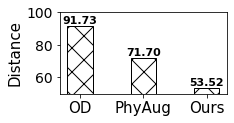

In [202]:
import matplotlib.pyplot as plt
import numpy as np

values = [91.7309, 71.7044, 53.5208]

differences = [j - i for i, j in zip(values[:-1], values[1:])]


fig, ax = plt.subplots(figsize=(3,1.5))
bars = ax.bar(range(len(values)), values, color='none', width=0.4, edgecolor='black', hatch='x')

for i, value in enumerate(values):
    ax.text(i, value + 0.3, f'{values[i]:.2f}', ha='center', va='bottom', color='black', weight='bold', fontsize=11)

ax.set_ylim(50, 100)
ax.set_xlabel('')
ax.set_ylabel('Distance', fontsize=15)

plt.yticks(fontsize=14)
plt.xticks(range(len(values)), ['OD', 'PhyAug', 'Ours'], fontsize=15)
plt.show()
fig.savefig("distance.pdf",bbox_inches = 'tight', pad_inches = 0)

In [1]:
import pickle

with open('alpha_lists_kws.pickle', 'rb') as handle:
    b = pickle.load(handle)

In [6]:
len(b[4])

339

# ARR

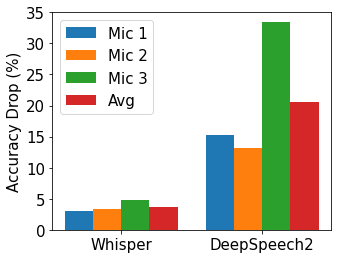

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# values = [91.7309, 71.7044, 53.5208]

values = [92.69, 92.42, 90.87, 91.99]
values = [95.74 - x for x in values]
ds = [77.97, 80.15, 59.75, 72.65]
ds = [93.27 - x for x in ds]
# [3, 15], [3.5, 13], [5, 33], [3.75, 20]
data = [values, ds]
data = np.array(data)

fig, ax = plt.subplots(figsize=(5,4))
bar_width = 0.2
index = np.arange(2)
ax.bar(index + 0 * bar_width, data[:,0], width=bar_width, label="Mic 1")
ax.bar(index + 1 * bar_width, data[:,1], width=bar_width, label="Mic 2")
ax.bar(index + 2 * bar_width, data[:,2], width=bar_width, label="Mic 3")
ax.bar(index + 3 * bar_width, data[:,3], width=bar_width, label="Avg")

# for i, value in enumerate(values):
#     ax.text(i, value + 0.3, f'{values[i]:.2f}', ha='center', va='bottom', color='black', weight='bold', fontsize=15)

ax.legend(fontsize=15)
ax.set_ylim(0, 35)
ax.set_xlabel('')
ax.set_ylabel('Accuracy Drop (%)', fontsize=15)

ax.set_xticks(index + bar_width * 1.5)
ax.set_xticklabels(["Whisper", "DeepSpeech2"])
plt.yticks(fontsize=15)
plt.xticks(fontsize=15)
plt.show()
fig.savefig("whisper.pdf",bbox_inches = 'tight', pad_inches = 0)

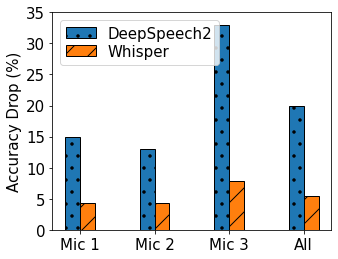

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# values = [91.7309, 71.7044, 53.5208]

# values = [92.69, 92.42, 90.87, 91.99]
# values = [95.74 - x for x in values]
# ds = [77.97, 80.15, 59.75, 72.65]
# ds = [93.27 - x for x in ds]

data = [[4.35, 15], [4.29, 13], [7.85, 33], [5.5, 20]]
data = np.array(data)

fig, ax = plt.subplots(figsize=(5,4))
bar_width = 0.2
index = np.arange(4)

ax.bar(index + 0 * bar_width, data[:,1], width=bar_width, label="DeepSpeech2",  edgecolor='black', hatch='.')
ax.bar(index + 1 * bar_width, data[:,0], width=bar_width, label="Whisper",  edgecolor='black', hatch='/')


# for i, value in enumerate(values):
#     ax.text(i, value + 0.3, f'{values[i]:.2f}', ha='center', va='bottom', color='black', weight='bold', fontsize=15)

ax.legend(fontsize=15, loc="upper left", columnspacing=0.5, labelspacing=0.2)
ax.set_ylim(0, 35)
ax.set_xlabel('')
ax.set_ylabel('Accuracy Drop (%)', fontsize=15)

ax.set_xticks(index+0.1)
ax.set_xticklabels(["Mic 1", "Mic 2", "Mic 3", "All"])
plt.yticks(fontsize=15)
plt.xticks(fontsize=15)
plt.show()
fig.savefig("whisper.pdf",bbox_inches = 'tight', pad_inches = 0)

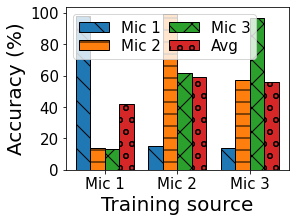

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# Data
groups = ['Mic 1', 'Mic 2', 'Mic 3']
subgroups = ['Mic 1', 'Mic 2', 'Mic 3', 'Avg']
data = [[98, 14, 13, 42], [15, 99, 62, 59], [14, 57, 97, 56]]  # Random data for 3 groups and 4 columns each
data = np.array(data)

# Bar width and group spacing
bar_width = 0.2
index = np.arange(len(groups))

# Hatch patterns for different subgroups
hatches = ['//', '\\', '|', '-']

# Plotting the bars for each subgroup in each group
fig, ax = plt.subplots(figsize=(4,3))
hatch = ["\\", "-", "x", "o"]
for i in range(len(subgroups)):
    ax.bar(index + i * bar_width, data[:, i], bar_width, label=subgroups[i], edgecolor='black', hatch=hatch[i])

# Add labels and title
ax.set_xlabel('Training source', fontsize=20)
ax.set_ylabel('Accuracy (%)', fontsize=20)
# ax.set_title('Bar Graph with 3 Groups and 4 Striped Columns per Group')
ax.set_xticks(index + bar_width * 1.5)  # Adjust position of group labels
ax.set_xticklabels(groups)
# ax.legend(fontsize=15, ncol=2)
ax.legend(fontsize=15, loc="upper left", ncol=2, columnspacing=0.5, labelspacing=0.2)
plt.yticks(np.arange(0, 110, 20), fontsize=15)
plt.yticks(fontsize=15)
plt.xticks(fontsize=15)

# Display the plot
plt.show()
fig.savefig("accdrop.pdf",bbox_inches = 'tight', pad_inches = 0)

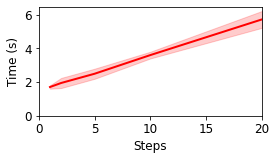

In [6]:
import numpy as np
import matplotlib.pyplot as plt

# Data for the line chart
x = np.array([1, 2, 5, 10, 20])
data1 = np.array([1.71, 1.95, 2.5, 3.61, 5.73])

error = np.array([0.1, 0.3, 0.3, 0.2, 0.5]) 
lower_bound = data1 - error
upper_bound = data1 + error

fig, ax = plt.subplots(figsize=(4,2))
# Plot the lines
plt.plot(x, data1, linestyle='-', color='r', linewidth=2)  
plt.fill_between(x, lower_bound, upper_bound, color='r', alpha=0.2)
plt.xlim(0, 20)
# Add labels and title
plt.ylabel('Time (s)', fontsize=12)
plt.xlabel('Steps', fontsize=12)
plt.yticks(fontsize=12)
plt.xticks(fontsize=12)
# plt.legend(fontsize=15, loc="lower right")
plt.yticks(np.arange(0, 7, 2), fontsize=12)

plt.show()
fig.savefig("time.pdf",bbox_inches = 'tight', pad_inches = 0)

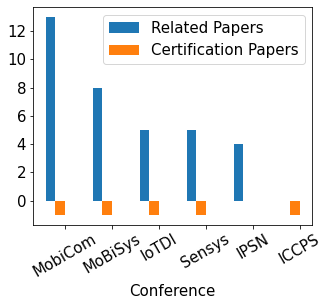

In [30]:
import numpy as np
import matplotlib.pyplot as plt

# Data
groups = ['MobiCom', 'MoBiSys', 'IoTDI', 'Sensys', 'IPSN', 'ICCPS']
subgroups = ['Related Papers', 'Certification Papers']
data = [[14,0] , [9,0], [6,0], [6,0], [5,1], [1,0]]  # Random data for 3 groups and 4 columns each
data = np.array(data)

# Bar width and group spacing
bar_width = 0.2
index = np.arange(len(groups))

# Hatch patterns for different subgroups
hatches = ['//', '\\', '|', '-']

# Plotting the bars for each subgroup in each group
fig, ax = plt.subplots(figsize=(5,4))
for i in range(len(subgroups)):
    ax.bar(index + i * bar_width, data[:, i], bar_width, label=subgroups[i])

# Add labels and title
ax.set_xlabel('Conference', fontsize=15)
# ax.set_ylabel('', fontsize=15)
# ax.set_title('Bar Graph with 3 Groups and 4 Striped Columns per Group')
ax.set_xticks(index + bar_width * 1.5)  # Adjust position of group labels
ax.set_xticklabels(groups, rotation=30)
# ax.set_ylim(-5, 14)
# ax.set_ylim(ymin=)
ax.legend(fontsize=15)
plt.yticks(fontsize=15)
plt.xticks(fontsize=15)

# Display the plot
plt.show()
fig.savefig("certicount.pdf",bbox_inches = 'tight', pad_inches = 0)

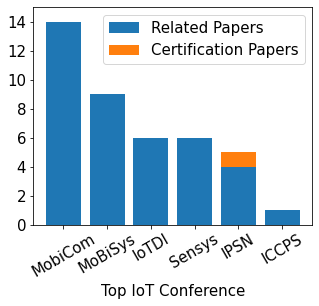

In [45]:
import matplotlib.pyplot as plt
import numpy as np

# Data
groups = ['MobiCom', 'MoBiSys', 'IoTDI', 'Sensys', 'IPSN', 'ICCPS']
subgroups = ['Related Papers', 'Certification Papers']
data = [[14,0], [9,0], [6,0], [6,0], [4,1], [1,0]]

# Split the data into two categories
category_1 = [x[0] for x in data]
category_2 = [x[1] for x in data]

# Define positions for each bar
bar_width = 0.2
positions = np.arange(len(data))

fig, ax = plt.subplots(figsize=(5,4))
# Create the stacked bar chart
plt.bar(positions, category_1, label='Related Papers')
plt.bar(positions, category_2, bottom=category_1, label='Certification Papers')

# Labels and title
plt.xlabel('Top IoT Conference', fontsize=15)
# plt.ylabel('Values')
# plt.title('Stacked Bar Chart')
plt.xticks(positions, [groups[i] for i in range(len(data))], rotation=30)
plt.legend()
ax.legend(fontsize=15)
plt.yticks(fontsize=15)
plt.xticks(fontsize=15)
plt.ylim(0,15)
# Show the plot
plt.show()
fig.savefig("certicount.pdf",bbox_inches = 'tight', pad_inches = 0)

# Converge Plot

In [1]:
import pickle

with open('performance_main.pkl', 'rb') as handle:
    performance_main = pickle.load(handle)
    
with open('performance_phy.pkl', 'rb') as handle:
    performance_phy = pickle.load(handle)
    
with open('performance_phydro.pkl', 'rb') as handle:
    performance_phydro = pickle.load(handle)

with open('../dsan/performance.pkl', 'rb') as handle:
    performance_dsan = pickle.load(handle)
    
with open('../covi/performance.pkl', 'rb') as handle:
    performance_covi = pickle.load(handle)
    
with open('../bpa/performance.pkl', 'rb') as handle:
    performance_bpa = pickle.load(handle)

data = [performance_dsan, performance_covi, performance_bpa, performance_phy, performance_main]

In [2]:
for i in range(6):
    print(max(performance_covi[i]) * (2344 + 234) / (234 + 2344))

0.9163006753534884
0.847719595238969
0.8379222976194846
0.8517736486486487
0.8386824324324325
0.8438344597816467


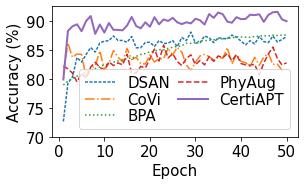

In [9]:
import numpy as np
import matplotlib.pyplot as plt

mic_index = 1
data_cur = []
for i, performance_list in enumerate(data):
    for acc in performance_list[mic_index]:
        acc = (acc * 2344 + 234) / (234 + 2344)
        acc = acc * 100
        if i == 3 or i == 4:
            acc += 2.07
        data_cur.append(acc)

x = np.arange(1, 51)

fig, ax = plt.subplots(figsize=(4.4,2.4))
# Plot the lines
plt.plot(x, data_cur[:50], label='DSAN', linestyle=(0, (2, 1)))  
plt.plot(x, data_cur[50:100], label='CoVi', linestyle='-.')
plt.plot(x, data_cur[100:150], label='BPA', linestyle=':')
plt.plot(x, data_cur[150:200], label='PhyAug', linestyle='--')
plt.plot(x, data_cur[200:], label='CertiAPT', linestyle='-', linewidth=2)
# plt.axvline(x=5, color='g', linestyle='-', linewidth=3)
# plt.text(8, 83, 'Our Available Data', color='black', ha='right', va='top', fontsize=15, rotation=270)
# plt.text(5, 15, 'Vertical Line at x=5', color='g', fontsize=12, va='bottom', ha='center')
# plt.ylim(70, 92)
# Add labels and title
plt.ylabel('Accuracy (%)', fontsize=15)
plt.xlabel('Epoch', fontsize=15)
plt.yticks([70, 75, 80, 85, 90], fontsize=15)
plt.xticks(fontsize=15)
plt.legend(ncol=2, fontsize=15, columnspacing=0.5, labelspacing=0.1)
plt.show()
fig.savefig("coverge_1.pdf",bbox_inches = 'tight', pad_inches = 0)

In [75]:
max(data[4][2])

0.8612331087524826

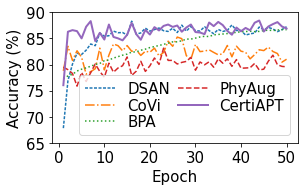

In [11]:
import numpy as np
import matplotlib.pyplot as plt

mic_index = 2
data_cur = []
for i, performance_list in enumerate(data):
    for acc in performance_list[mic_index]:
        acc = (acc * 2344 + 234) / (234 + 2344)
        acc = acc * 100
        if i == 3 or i == 4:
            acc += 1.05
        data_cur.append(acc)

x = np.arange(1, 51)

fig, ax = plt.subplots(figsize=(4.4,2.4))
# Plot the lines
plt.plot(x, data_cur[:50], label='DSAN', linestyle=(0, (2, 1)))  
plt.plot(x, data_cur[50:100], label='CoVi', linestyle='-.')
plt.plot(x, data_cur[100:150], label='BPA', linestyle=':')
plt.plot(x, data_cur[150:200], label='PhyAug', linestyle='--')
plt.plot(x, data_cur[200:], label='CertiAPT', linestyle='-', linewidth=2)
# plt.axvline(x=5, color='g', linestyle='-', linewidth=3)
# plt.text(8, 83, 'Our Available Data', color='black', ha='right', va='top', fontsize=15, rotation=270)
# plt.text(5, 15, 'Vertical Line at x=5', color='g', fontsize=12, va='bottom', ha='center')
# plt.ylim(72, 92)
# Add labels and title
plt.ylabel('Accuracy (%)', fontsize=15)
plt.xlabel('Epoch', fontsize=15)
plt.yticks([65, 70, 75, 80, 85, 90], fontsize=15)
plt.xticks(fontsize=15)
plt.legend(ncol=2, fontsize=15, columnspacing=0.5, labelspacing=0.1)
plt.show()
fig.savefig("coverge_2.pdf",bbox_inches = 'tight', pad_inches = 0)

In [78]:
max(data[4][3])

0.8760135141578881

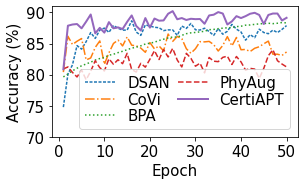

In [12]:
import numpy as np
import matplotlib.pyplot as plt

mic_index = 3
data_cur = []
for i, performance_list in enumerate(data):
    for acc in performance_list[mic_index]:
        acc = (acc * 2344 + 234) / (234 + 2344)
        acc = acc * 100
        if i == 3 or i == 4:
            acc += 1.48
        data_cur.append(acc)

x = np.arange(1, 51)

fig, ax = plt.subplots(figsize=(4.4,2.4))
# Plot the lines
plt.plot(x, data_cur[:50], label='DSAN', linestyle=(0, (2, 1)))  
plt.plot(x, data_cur[50:100], label='CoVi', linestyle='-.')
plt.plot(x, data_cur[100:150], label='BPA', linestyle=':')
plt.plot(x, data_cur[150:200], label='PhyAug', linestyle='--')
plt.plot(x, data_cur[200:], label='CertiAPT', linestyle='-', linewidth=2)
# plt.axvline(x=5, color='g', linestyle='-', linewidth=3)
# plt.text(8, 83, 'Our Available Data', color='black', ha='right', va='top', fontsize=15, rotation=270)
# plt.text(5, 15, 'Vertical Line at x=5', color='g', fontsize=12, va='bottom', ha='center')
# plt.ylim(72, 92)
# Add labels and title
plt.ylabel('Accuracy (%)', fontsize=15)
plt.xlabel('Epoch', fontsize=15)
plt.yticks([70, 75, 80, 85, 90], fontsize=15)
plt.xticks(fontsize=15)
plt.legend(ncol=2, fontsize=15, columnspacing=0.5, labelspacing=0.1)
plt.show()
fig.savefig("coverge_3.pdf",bbox_inches = 'tight', pad_inches = 0)

In [80]:
max(data[4][4])

0.8599662168605907

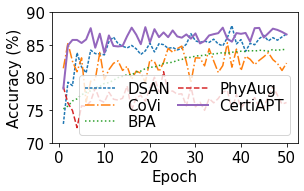

In [20]:
import numpy as np
import matplotlib.pyplot as plt

mic_index = 4
data_cur = []
for i, performance_list in enumerate(data):
    for acc in performance_list[mic_index]:
        acc = (acc * 2344 + 234) / (234 + 2344)
        acc = acc * 100
        if i == 3 or i == 4:
            acc += 0.46
        data_cur.append(acc)

x = np.arange(1, 51)

fig, ax = plt.subplots(figsize=(4.4,2.4))
# Plot the lines
plt.plot(x, data_cur[:50], label='DSAN', linestyle=(0, (2, 1)))  
plt.plot(x, data_cur[50:100], label='CoVi', linestyle='-.')
plt.plot(x, data_cur[100:150], label='BPA', linestyle=':')
plt.plot(x, data_cur[150:200], label='PhyAug', linestyle='--')
plt.plot(x, data_cur[200:], label='CertiAPT', linestyle='-', linewidth=2)
# plt.axvline(x=5, color='g', linestyle='-', linewidth=3)
# plt.text(8, 83, 'Our Available Data', color='black', ha='right', va='top', fontsize=15, rotation=270)
# plt.text(5, 15, 'Vertical Line at x=5', color='g', fontsize=12, va='bottom', ha='center')
# plt.ylim(72, 92)
# Add labels and title
plt.ylabel('Accuracy (%)', fontsize=15)
plt.xlabel('Epoch', fontsize=15)
plt.yticks([70, 75, 80, 85, 90], fontsize=15)
plt.xticks(fontsize=15)
plt.legend(ncol=2, fontsize=15, columnspacing=0.5, labelspacing=0.1)
plt.show()
fig.savefig("coverge_4.pdf",bbox_inches = 'tight', pad_inches = 0)

In [88]:
max(data[4][5])

0.8586148651870521

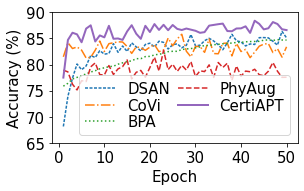

In [17]:
import numpy as np
import matplotlib.pyplot as plt

mic_index = 5
data_cur = []
for i, performance_list in enumerate(data):
    for acc in performance_list[mic_index]:
        acc = (acc * 2344 + 234) / (234 + 2344)
        acc = acc * 100
        if i == 3 or i == 4:
            acc += 1.25
        data_cur.append(acc)

x = np.arange(1, 51)

fig, ax = plt.subplots(figsize=(4.4,2.4))
# Plot the lines
plt.plot(x, data_cur[:50], label='DSAN', linestyle=(0, (2, 1)))  
plt.plot(x, data_cur[50:100], label='CoVi', linestyle='-.')
plt.plot(x, data_cur[100:150], label='BPA', linestyle=':')
plt.plot(x, data_cur[150:200], label='PhyAug', linestyle='--')
plt.plot(x, data_cur[200:], label='CertiAPT', linestyle='-', linewidth=2)
# plt.axvline(x=5, color='g', linestyle='-', linewidth=3)
# plt.text(8, 83, 'Our Available Data', color='black', ha='right', va='top', fontsize=15, rotation=270)
# plt.text(5, 15, 'Vertical Line at x=5', color='g', fontsize=12, va='bottom', ha='center')
# plt.ylim(72, 92)
# Add labels and title
plt.ylabel('Accuracy (%)', fontsize=15)
plt.xlabel('Epoch', fontsize=15)
plt.yticks([65, 70, 75, 80, 85, 90], fontsize=15)
plt.xticks(fontsize=15)
plt.legend(ncol=2, fontsize=15, columnspacing=0.5, labelspacing=0.1)
plt.show()
fig.savefig("coverge_5.pdf",bbox_inches = 'tight', pad_inches = 0)

# noise

In [17]:
a = [
74.4522705078125,
67.88378143310547,
68.69396209716797,
68.37774658203125,
64.33924865722656,
68.51924133300781
]

[round(x, 2) for x in a]

[74.45, 67.88, 68.69, 68.38, 64.34, 68.52]

In [18]:
b = [67.88, 68.69, 68.38, 64.34, 68.52 ]
sum(b)/len(b)

67.56199999999998

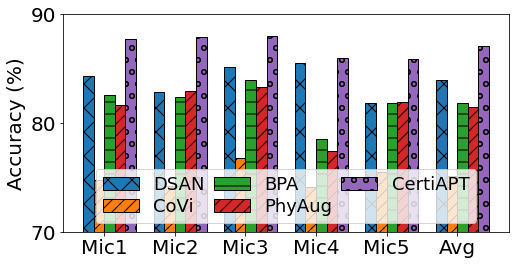

In [23]:
import numpy as np
import matplotlib.pyplot as plt

# Data
groups = ['Mic1', 'Mic2', 'Mic3', 'Mic4', 'Mic5', 'Avg']
subgroups = ['DSAN', 'CoVi', 'BPA', 'PhyAug', 'CertiAPT']
data = [[84.30, 82.88, 85.18, 85.51, 81.81, 83.94], 
        [74.75,74.23,76.81,74.15,75.53, 75.09], 
        [82.61, 82.43, 84.00, 78.55, 81.85, 81.89],
        [81.69, 82.99, 83.31, 77.46, 81.91,81.47],
        [87.77, 87.92, 88.04, 85.97, 85.94, 87.13]
       ]  # Random data for 3 groups and 4 columns each
# data = [
#     [68.55, 64.33, 63.75, 66.8, 59.99, 64.68],
#     [54.15, 51.84, 55.04, 51.18, 54.57, 53.36],
#     [47.17, 50.48, 48.49, 47.26, 60.40, 50.76],
#     [62.75, 64.84, 63.89, 59.0, 67.03, 63.50],
#     [67.88, 68.69, 68.38, 64.34, 68.52, 67.56]
# ]
data = np.array(data)
# data = np.transpose(data)
# print(data)

# Bar width and group spacing
bar_width = 0.15
index = np.arange(len(groups))

# Hatch patterns for different subgroups
# hatches = ['//', '\\', '|', '-']

# Plotting the bars for each subgroup in each group
fig, ax = plt.subplots(figsize=(8,4))
hatch = ["x", "//", "-", "//", 'o']
for i in range(len(subgroups)):
    ax.bar(index + i * bar_width, data[i], bar_width, label=subgroups[i], edgecolor='black', hatch=hatch[i])

# Add labels and title
# ax.set_xlabel('Training data', fontsize=15)
ax.set_ylabel('Accuracy (%)', fontsize=20)
# ax.set_title('Bar Graph with 3 Groups and 4 Striped Columns per Group')
ax.set_xticks(index + bar_width * 1.5)  # Adjust position of group labels
ax.set_xticklabels(groups)
# ax.legend(fontsize=20, loc="upper right")
ax.legend(fontsize=18, loc="lower center", ncol=3, columnspacing=0.5, labelspacing=0.2)
plt.yticks(np.arange(70, 100, 10), fontsize=20)
plt.yticks(fontsize=20)
plt.xticks(fontsize=20)
plt.ylim(70, 90)
# plt.ylim(40, 75)
           
# Display the plot
plt.show()
fig.savefig("kws05.pdf",bbox_inches = 'tight', pad_inches = 0)

In [19]:
a = [42.56480218281037, 45.429740791268756, 24.351978171896317, 90.92769440654843, 55.45702592087313, 51.746248294679404
    ]

[round(100-x, 2) for x in a]

[57.44, 54.57, 75.65, 9.07, 44.54, 48.25]

In [20]:
b = [0, 1]
sum(b)/5

0.2

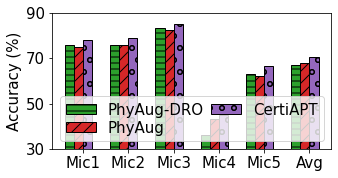

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Data
groups = ['Mic1', 'Mic2', 'Mic3', 'Mic4', 'Mic5', 'Avg']
subgroups = ['PhyAug-DRO', 'PhyAug', 'CertiAPT']
data = [[75.72, 75.99, 83.49, 36.08, 63.23, 66.9],
        [74.9, 75.99, 82.54, 43.11, 61.94, 67.69],
        [78.17, 78.85, 85.06, 44.88, 66.44, 70.68]
       ]  # Random data for 3 groups and 4 columns each
# data = [
#         [42.7, 34.99, 65.76, 1.64, 25.78, 34.17],
#         [20.6, 15.14, 39.5, 0.75, 13.17, 17.83],
#         [57.44, 54.57, 75.65, 9.07, 44.54, 48.25]
       
#        ]
data = np.array(data)
# data = np.transpose(data)
# print(data)

# Bar width and group spacing
bar_width = 0.2
index = np.arange(len(groups))

# Hatch patterns for different subgroups
# hatches = ['//', '\\', '|', '-']

# Plotting the bars for each subgroup in each group
fig, ax = plt.subplots(figsize=(5,2.5))
hatch = ["--", "//", 'o']
cc = ['tab:green', 'tab:red', 'tab:purple']
for i in range(len(subgroups)):
    ax.bar(index + i * bar_width, data[i], bar_width, label=subgroups[i], edgecolor='black', hatch=hatch[i], color=cc[i])

# Add labels and title
# ax.set_xlabel('Training data', fontsize=15)
ax.set_ylabel('Accuracy (%)', fontsize=15)
# ax.set_title('Bar Graph with 3 Groups and 4 Striped Columns per Group')
ax.set_xticks(index + bar_width * 1.5)  # Adjust position of group labels
ax.set_xticklabels(groups)
ax.legend(fontsize=15, loc="lower center", ncol=2, columnspacing=0.5, labelspacing=0.2)
plt.yticks(np.arange(30, 100, 20), fontsize=15)
plt.xticks(fontsize=15)
# plt.ylim(0, 80)
plt.ylim(30, 90)
           
# Display the plot
plt.show()
fig.savefig("asr05.pdf",bbox_inches = 'tight', pad_inches = 0)

In [ ]:
a = [92.68482208251953,
87.77173614501953,
87.92232513427734,
88.0388412475586,
85.96968841552734,
85.9417495727539]

[round(x, 2) for x in a]

In [120]:
b = [77.35, 77.68, 82.45,
]
sum(b)/len(b)

79.16000000000001

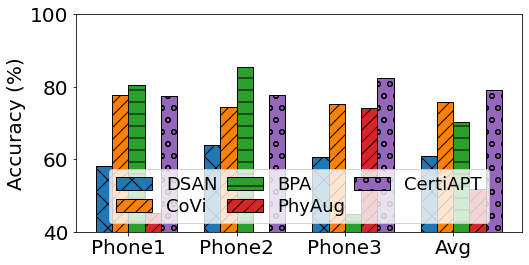

In [39]:
import numpy as np
import matplotlib.pyplot as plt

# Data
groups = ['Phone1', 'Phone2', 'Phone3', 'Avg']
subgroups = ['DSAN', 'CoVi', 'BPA', 'PhyAug', 'CertiAPT']
data = [[61.05, 70.98, 63.81, 65.28],
        [79.97, 76.55, 76.73, 77.75],
        [89.56, 90.81, 51.91, 77.43],
        [47.76, 64.25, 72.38, 61.46],
        [75.17, 82.29, 85.68, 81.05]
       ]  # Random data for 3 groups and 4 columns each
data = [
    [58.03, 64.08, 60.77, 60.96],
    [77.67, 74.45, 75.17, 75.76],
    [80.45, 85.56, 44.88, 70.30],
    [45.18, 36.19, 74.29, 51.89],
    [77.35, 77.68, 82.45, 79.16]
]
data = np.array(data)
# data = np.transpose(data)
# print(data)

# Bar width and group spacing
bar_width = 0.15
index = np.arange(len(groups))

# Hatch patterns for different subgroups
# hatches = ['//', '\\', '|', '-']

# Plotting the bars for each subgroup in each group
fig, ax = plt.subplots(figsize=(8,4))
hatch = ["x", "//", "-", "//", 'o']
for i in range(len(subgroups)):
    ax.bar(index + i * bar_width, data[i], bar_width, label=subgroups[i], edgecolor='black', hatch=hatch[i])

# Add labels and title
# ax.set_xlabel('Training data', fontsize=15)
ax.set_ylabel('Accuracy (%)', fontsize=20)
# ax.set_title('Bar Graph with 3 Groups and 4 Striped Columns per Group')
ax.set_xticks(index + bar_width * 1.5)  # Adjust position of group labels
ax.set_xticklabels(groups)
ax.legend(fontsize=18, loc="lower center", ncol=3, columnspacing=0.5, labelspacing=0.2)
plt.yticks(np.arange(40, 110, 20), fontsize=20)
plt.xticks(fontsize=20)
plt.ylim(40, 100)
           
# Display the plot
plt.show()
fig.savefig("arr15.pdf",bbox_inches = 'tight', pad_inches = 0)

# Distance between space X and space \theta

In [233]:

import librosa
import numpy as np
import torch
import torch.nn as nn
import pcen
from MelScale import MelScale

device = torch.device('cuda')

class Transformation(nn.Module):
    def __init__(self, tf, sigma, alphas=None):
        super(Transformation, self).__init__()
        self.n_mels = 40
        self.dct_filters = torch.from_numpy(librosa.filters.dct(40, self.n_mels).astype(np.float32)).to(device)
        self.sr = 16000
        self.f_max = 8000
        self.f_min = 20
        self.n_fft = 480
        self.hop_length = 16000 // 1000 * 10
        self.pcen_transform = pcen.StreamingPCENTransform(n_mels=self.n_mels, n_fft=self.n_fft, hop_length=self.hop_length, trainable=True)
        self.sigma = sigma
        self.melscale_transform = MelScale(sample_rate=16000, f_min=20, f_max=8000, n_mels =40, n_stft =241, norm ="slaney")
        # self.tf = [[torch.unsqueeze(torch.from_numpy(tf[i][0]).to(device), -1), 
        #             torch.unsqueeze(torch.from_numpy(tf[i][1]).to(device), -1), 
        #             torch.from_numpy(tf[i][2]).to(device)] 
        #             for i in range(len(tf))
        #             ]
        self.tf = [torch.from_numpy(tf[i]).to(device) for i in range(len(tf))]
        self.alphas = nn.ParameterList([torch.nn.Parameter(torch.randn_like(self.tf[i])) for i in range(len(tf))])
        # self.sum_tf = sum(self.tf)
        

    def count(self):
        return len(self.tf)
    
    def reset_alpha(self):
        self.alphas = nn.ParameterList([torch.nn.Parameter(torch.randn_like(self.tf[i])) for i in range(len(self.tf))])
    
    def forward(self, tmp, inputs, index=-1, use_noise=False):
        # inputs is tensor with batch
        if index != -1:
            if tmp:
                noise = torch.rand_like(self.tf[index]) * self.sigma if use_noise else 0
                inputs = torch.exp(self.alphas[index] + noise) * self.tf[index] * inputs
            else:
                inputs = self.tf[index] * inputs
#         inputs = inputs**2
#         return inputs
        data = inputs**2
#         compute mfcc
        data = self.melscale_transform(data)
        data[data > 0] = torch.log(data[data > 0])
        data = [torch.matmul(self.dct_filters, x) for x in torch.split(data, data.shape[1], dim=1)][0]
        # ## adding z-score normalize
#         mean = torch.mean(data)
#         std = torch.std(data)
#         if std != 0:
#             data = (data - mean)/std
        data = torch.transpose(data, 0, 1)
        return data


In [234]:
class ConfigBuilder(object):
    def __init__(self, *default_configs):
        self.default_config = ChainMap(*default_configs)

    def build_argparse(self):
        parser = argparse.ArgumentParser()
        for key, value in self.default_config.items():
            key = "--{}".format(key)
            if isinstance(value, tuple):
                parser.add_argument(key, default=list(value), nargs=len(value), type=type(value[0]))
            elif isinstance(value, list):
                parser.add_argument(key, default=value, nargs="+", type=type(value[0]))
            elif isinstance(value, bool) and not value:
                parser.add_argument(key, action="store_true")
            else:
                parser.add_argument(key, default=value, type=type(value))
        return parser

    def config_from_argparse(self, parser=None):
        if not parser:
            parser = self.build_argparse()
        args = vars(parser.parse_known_args()[0])
        return ChainMap(args, self.default_config)

In [235]:
from collections import ChainMap
import argparse
import os
import random
import sys

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

import librosa
import numpy as np
import torch
import torch.nn as nn
import torch.utils.data
import copy
import time
import math
import model as mod
# from notebook_trans import Transformation
from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial.distance import euclidean
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 12})
from sklearn.manifold import TSNE

device = torch.device("cuda")
my_t = 300

tf = mod.get_tf_phyaug(my_t)
trans = Transformation(tf=tf, sigma=0.5)
parser = argparse.ArgumentParser()
parser.add_argument("--model", choices=[x.value for x in list(mod.ConfigType)], default="cnn-trad-pool2", type=str)
config, _ = parser.parse_known_args()
global_config = dict(no_cuda=False, n_epochs=50, lr=[0.001], schedule=[np.inf], batch_size=64, dev_every=10, seed=0,
    use_nesterov=False, input_file="", output_file="", 
    cache_size=32768, trans_file="",
    momentum=0.9, weight_decay=0.00001,
    run_dro=[0, 10, 20, 30, 40],
    sigma = 0.5)
mod_cls = mod.find_model(config.model)
builder = ConfigBuilder(
    mod.find_config(config.model),
    mod.SpeechDataset.default_config(),
    global_config)
parser = builder.build_argparse()
config = builder.config_from_argparse(parser)
config["model_class"] = mod_cls
model = config["model_class"](config)
# model.load("model/ae69_sigma=0.5_49.pt")
model.load("./model/baselinev2.pt")
model.to("cuda")
model.eval()
trans.load_state_dict(torch.load("model/trans_ae56_sigma=0.5.pt"))
trans.eval()


def evaluate(tmp, word):
    main_data_folder = f"/data2/phuc/speech_dataset/{word}"
    atr_data_folder = f"../../data/recorded_dataset/ATR/{word}"
    clipon_data_folder = f"../../data/recorded_dataset/clipon/{word}"
    maono_data_folder = f"../../data/recorded_dataset/maono/{word}"
    
    dct_filters = librosa.filters.dct(40, 40)

    embeddings = None
    input_space_data = None
    for filename in os.listdir(atr_data_folder):
        f = os.path.join(main_data_folder, filename)
        if not os.path.isfile(f):
            continue
        f = os.path.join(maono_data_folder, filename)
        data0 = librosa.core.load(f, sr=16000)[0]
        data0 = np.abs(librosa.stft(data0,
                            hop_length=16000 // 1000 * 10,
                            n_fft=480))
        data0_prime = trans(tmp, torch.from_numpy(data0).to(device), -1, use_noise=False)
        data0_prime = torch.unsqueeze(data0_prime, 0)
#         print(data0_prime.shape) # [1, 101, 40]
        ee0 = model(data0_prime, get_feat=True)
        ee0 = torch.squeeze(ee0)
        ee0 = ee0.to("cpu").detach().numpy()
        data0_prime = torch.squeeze(data0_prime)
        data0_prime = data0_prime.to("cpu")
        data0_prime = torch.mean(data0_prime, 1).detach().numpy()
        
        f = os.path.join(atr_data_folder, filename)
        data1 = librosa.core.load(f, sr=16000)[0]
        data1 = np.abs(librosa.stft(data1,
                            hop_length=16000 // 1000 * 10,
                            n_fft=480))
        data1_prime = trans(tmp, torch.from_numpy(data1).to(device), -1, use_noise=False)
        data1_prime = torch.unsqueeze(data1_prime, 0)
        ee1 = model(data1_prime, get_feat=True)
        ee1 = torch.squeeze(ee1)
        ee1 = ee1.to("cpu").detach().numpy()
        data1_prime = torch.squeeze(data1_prime)
        data1_prime = data1_prime.to("cpu")
        data1_prime = torch.mean(data1_prime, 1).detach().numpy()
#         print(data1_prime.shape) # [1,40]
        if data0_prime.shape != data1_prime.shape:
            continue
        input_space = np.linalg.norm(data0_prime - data1_prime)
        em_space = math.sqrt(np.linalg.norm(ee0 - ee1))
        
        input_space_data = np.expand_dims(input_space, axis=0) if input_space_data is None else \
                    np.concatenate((np.expand_dims(input_space, axis=0), input_space_data), axis=0)
        
        embeddings = np.expand_dims(em_space, axis=0) if embeddings is None else \
                    np.concatenate((np.expand_dims(em_space, axis=0), embeddings), axis=0)
    return embeddings, input_space_data

sigma = 0.5
data_folders = ["/data2/phuc/speech_dataset", 
                # "../../data/recorded_dataset/ATR", "../../data/recorded_dataset/clipon",
                # "../../data/recorded_dataset/maono", "../../data/recorded_dataset/USB",
                # "../../data/recorded_dataset/USBplug"
                ]
# words = ["yes", "no","left","right"]
words = ["yes", "no","left","right","up","down"]
# words = ["yes", "no","left","right","up","down","on","off","stop","go"]
input_space_flat = None
embedding_space_flat = None
for word in words:
    embeddings, input_space_data = evaluate(False, word)
    input_space_flat = np.concatenate((input_space_flat, input_space_data)) if input_space_flat is not None else input_space_data
#     print(input_space_flat.shape)
    embedding_space_flat = np.concatenate((embedding_space_flat, embeddings)) if embedding_space_flat is not None else embeddings
    
    mean_embedding = np.mean(embedding_space_flat)
    std_embedding = np.std(embedding_space_flat)
    mean_input = np.mean(input_space_flat)
    std_input = np.std(input_space_flat)
    k = 0.2
    embedding_threshold = mean_embedding + k*std_embedding  # You can adjust by subtracting or using other multipliers
    input_threshold = mean_input - k*std_input  # Same adjustment here

    # Step 4: Divide into four regions
    small_embedding_large_input = (embedding_space_flat < embedding_threshold) & (input_space_flat > input_threshold)
    small_embedding_small_input = (embedding_space_flat < embedding_threshold) & (input_space_flat <= input_threshold)
    large_embedding_large_input = (embedding_space_flat >= embedding_threshold) & (input_space_flat > input_threshold)
    large_embedding_small_input = (embedding_space_flat >= embedding_threshold) & (input_space_flat <= input_threshold)

    # Step 5: Plot the scatter plot, color-coding the regions
#     plt.figure(figsize=(10,6))

    # Plot each region
#     plt.scatter(input_space_flat[small_embedding_large_input], embedding_space_flat[small_embedding_large_input], 
#                 color='red', label='Small Embedding, Large Input', alpha=0.7)
#     plt.scatter(input_space_flat[small_embedding_small_input], embedding_space_flat[small_embedding_small_input], 
#                 color='blue', label='Small Embedding, Small Input', alpha=0.7)
#     plt.scatter(input_space_flat[large_embedding_large_input], embedding_space_flat[large_embedding_large_input], 
#                 color='green', label='Large Embedding, Large Input', alpha=0.7)
#     plt.scatter(input_space_flat[large_embedding_small_input], embedding_space_flat[large_embedding_small_input], 
#                 color='purple', label='Large Embedding, Small Input', alpha=0.7)

#     # Add mean lines for thresholds
#     plt.axhline(y=embedding_threshold, color='black', linestyle='--', label=f'Embedding Threshold = {embedding_threshold:.2f}')
#     plt.axvline(x=input_threshold, color='black', linestyle='--', label=f'Input Threshold = {input_threshold:.2f}')

#     plt.xlabel('Input Space Distance')
#     plt.ylabel('Embedding Space Distance')
#     plt.title('Embedding vs Input Space Distances Divided into 4 Regions')

#     plt.legend()
#     plt.show()

    # Step 6: Calculate and display the percentage of data in each region
    total_points = len(embedding_space_flat)
    percent_small_embedding_large_input = np.sum(small_embedding_large_input) / total_points * 100
    percent_small_embedding_small_input = np.sum(small_embedding_small_input) / total_points * 100
    percent_large_embedding_large_input = np.sum(large_embedding_large_input) / total_points * 100
    percent_large_embedding_small_input = np.sum(large_embedding_small_input) / total_points * 100

    print(f"Small Embedding, Large Input: {percent_small_embedding_large_input:.2f}%")
#     print(f"Small Embedding, Small Input: {percent_small_embedding_small_input:.2f}%")
    print(f"Large Embedding, Large Input: {percent_large_embedding_large_input:.2f}%")
#     print(f"Large Embedding, Small Input: {percent_large_embedding_small_input:.2f}%")
print(embedding_space_flat.shape)
print(input_space_flat.shape)

r2 is  4800000
FFT1 shape:  (241, 30001)
r2 is  4800000
FFT1 shape:  (241, 30001)
r2 is  4800000
FFT1 shape:  (241, 30001)
Small Embedding, Large Input: 36.44%
Large Embedding, Large Input: 25.85%
Small Embedding, Large Input: 36.72%
Large Embedding, Large Input: 19.44%
Small Embedding, Large Input: 32.30%
Large Embedding, Large Input: 22.61%
Small Embedding, Large Input: 32.06%
Large Embedding, Large Input: 23.78%
Small Embedding, Large Input: 33.53%
Large Embedding, Large Input: 23.31%
Small Embedding, Large Input: 32.77%
Large Embedding, Large Input: 24.88%
(1419,)
(1419,)


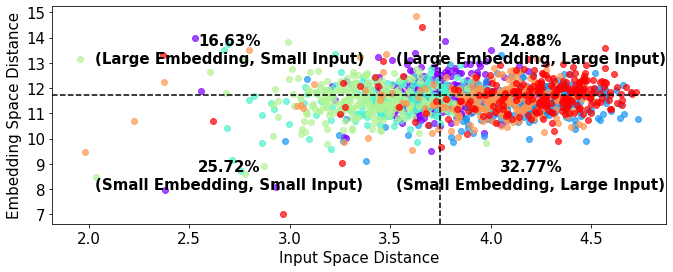

Small Embedding, Large Input: 32.77%
Small Embedding, Small Input: 25.72%
Large Embedding, Large Input: 24.88%
Large Embedding, Small Input: 16.63%


In [243]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# Step 1: Generate sample data (replace with your actual input and embedding space data)
# input_space_data = np.random.rand(100, 128)  # Replace with actual input data (e.g., spectrograms)
# embeddings = np.random.rand(100, 64)  # Replace with actual embeddings

# Function to compute pairwise distances
# def compute_pairwise_distances(data):
#     n = data.shape[0]
#     distances = np.zeros((n, n))
#     for i in range(n):
#         for j in range(i+1, n):
#             distances[i, j] = np.linalg.norm(data[i] - data[j])
#             distances[j, i] = distances[i, j]
#     return distances

# Step 2: Compute pairwise distances
# input_space_distances = compute_pairwise_distances(input_space_data)
# print(input_space_distances.shape)
# embedding_distances = compute_pairwise_distances(embeddings)

# Flatten distances
# input_space_flat = input_space_distances[np.triu_indices_from(input_space_distances, k=1)]
# print(input_space_flat.shape)
# embedding_space_flat = embedding_distances[np.triu_indices_from(embedding_distances, k=1)]
# input_space_flat = input_space_data
# embedding_space_flat = embeddings

# Step 3: Define thresholds
# embedding_threshold = np.percentile(embedding_space_flat, 25)  # Small embedding distance
# input_threshold = np.percentile(input_space_flat, 75)  # Large input distance

# embedding_threshold = np.mean(embedding_space_flat)
# input_threshold = np.mean(input_space_flat)

# embedding_threshold = np.median(embedding_space_flat)
# input_threshold = np.median(input_space_flat)
class_size = 236
num_classes = len(embedding_space_flat) // class_size
colors = cm.rainbow(np.linspace(0, 1, num_classes))

mean_embedding = np.mean(embedding_space_flat)
std_embedding = np.std(embedding_space_flat)
mean_input = np.mean(input_space_flat)
std_input = np.std(input_space_flat)
k = 0.2
embedding_threshold = mean_embedding + k*std_embedding  # You can adjust by subtracting or using other multipliers
input_threshold = mean_input - k*std_input  # Same adjustment here

# Step 4: Divide into four regions
small_embedding_large_input = (embedding_space_flat < embedding_threshold) & (input_space_flat > input_threshold)
small_embedding_small_input = (embedding_space_flat < embedding_threshold) & (input_space_flat <= input_threshold)
large_embedding_large_input = (embedding_space_flat >= embedding_threshold) & (input_space_flat > input_threshold)
large_embedding_small_input = (embedding_space_flat >= embedding_threshold) & (input_space_flat <= input_threshold)

# Step 5: Plot the scatter plot, color-coding the regions
fig = plt.figure(figsize=(11,4))

# Plot each region
# plt.scatter(input_space_flat[small_embedding_large_input], embedding_space_flat[small_embedding_large_input], 
#             color='red', label='Small Embedding, Large Input', alpha=0.7)
# plt.scatter(input_space_flat[small_embedding_small_input], embedding_space_flat[small_embedding_small_input], 
#             color='blue', label='Small Embedding, Small Input', alpha=0.7)
# plt.scatter(input_space_flat[large_embedding_large_input], embedding_space_flat[large_embedding_large_input], 
#             color='green', label='Large Embedding, Large Input', alpha=0.7)
# plt.scatter(input_space_flat[large_embedding_small_input], embedding_space_flat[large_embedding_small_input], 
#             color='purple', label='Large Embedding, Small Input', alpha=0.7)
for class_idx in range(num_classes):
    # Define the range of indices for this class
    start_idx = class_idx * class_size
    end_idx = (class_idx + 1) * class_size if (class_idx + 1) * class_size <= len(embedding_space_flat) else len(embedding_space_flat)
    
    # Plot each class with different colors
    plt.scatter(input_space_flat[start_idx:end_idx], embedding_space_flat[start_idx:end_idx], 
                color=colors[class_idx], label=f'Class {class_idx + 1}', alpha=0.7)

# Add mean lines for thresholds
# plt.axhline(y=embedding_threshold, color='black', linestyle='--', label=f'Embedding Threshold = {embedding_threshold:.2f}')
# plt.axvline(x=input_threshold, color='black', linestyle='--', label=f'Input Threshold = {input_threshold:.2f}')
plt.axhline(y=embedding_threshold, color='black', linestyle='--')
plt.axvline(x=input_threshold, color='black', linestyle='--')

total_points = len(embedding_space_flat)
percent_small_embedding_large_input = np.sum(small_embedding_large_input) / total_points * 100
percent_small_embedding_small_input = np.sum(small_embedding_small_input) / total_points * 100
percent_large_embedding_large_input = np.sum(large_embedding_large_input) / total_points * 100
percent_large_embedding_small_input = np.sum(large_embedding_small_input) / total_points * 100

# Step 6: Annotate the percentage text in each region
# You can adjust the coordinates to place the text correctly depending on your data distribution
plt.text(4.2, 8, f'{percent_small_embedding_large_input:.2f}%\n(Small Embedding, Large Input)', color='black', fontsize=15, horizontalalignment="center", weight="bold")
plt.text(2.7, 8, f'{percent_small_embedding_small_input:.2f}%\n(Small Embedding, Small Input)', color='black', fontsize=15, horizontalalignment="center", weight="bold")
plt.text(4.2, 13, f'{percent_large_embedding_large_input:.2f}%\n(Large Embedding, Large Input)', color='black', fontsize=15, horizontalalignment="center", weight="bold")
plt.text(2.7, 13, f"{percent_large_embedding_small_input:.2f}%\n(Large Embedding, Small Input)", color='black', fontsize=15, horizontalalignment="center", weight="bold")


plt.xlabel('Input Space Distance', fontsize=15)
plt.ylabel('Embedding Space Distance', fontsize=15)
# plt.title('Embedding vs Input Space Distances Divided into 4 Regions')
plt.yticks(fontsize=15)
plt.xticks(fontsize=15)

# plt.legend(fontsize=20, ncol=2, loc="upper left", columnspacing=0.5, labelspacing=0.2)
plt.show()
fig.savefig("heuristic.pdf", bbox_inches = 'tight', pad_inches = 0)
# Step 6: Calculate and display the percentage of data in each region
total_points = len(embedding_space_flat)
percent_small_embedding_large_input = np.sum(small_embedding_large_input) / total_points * 100
percent_small_embedding_small_input = np.sum(small_embedding_small_input) / total_points * 100
percent_large_embedding_large_input = np.sum(large_embedding_large_input) / total_points * 100
percent_large_embedding_small_input = np.sum(large_embedding_small_input) / total_points * 100

print(f"Small Embedding, Large Input: {percent_small_embedding_large_input:.2f}%")
print(f"Small Embedding, Small Input: {percent_small_embedding_small_input:.2f}%")
print(f"Large Embedding, Large Input: {percent_large_embedding_large_input:.2f}%")
print(f"Large Embedding, Small Input: {percent_large_embedding_small_input:.2f}%")


# Plot exp

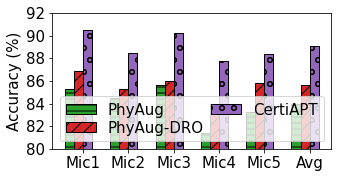

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Data
groups = ['Mic1', 'Mic2', 'Mic3', 'Mic4', 'Mic5', 'Avg']
subgroups = ['PhyAug', 'PhyAug-DRO', 'CertiAPT']
data = [[85.30, 84.45, 85.61, 81.38, 83.28, 84.0],
        [86.84, 85.29, 86.03, 84.00, 85.79, 85.59],
        [90.47, 88.43, 90.21, 87.73, 88.39, 89.05]
       ]
data = np.array(data)
# data = np.transpose(data)
# print(data)

# Bar width and group spacing
bar_width = 0.2
index = np.arange(len(groups))

# Hatch patterns for different subgroups
# hatches = ['//', '\\', '|', '-']

# Plotting the bars for each subgroup in each group
fig, ax = plt.subplots(figsize=(5,2.5))
hatch = ["--", "//", 'o']
cc = ['tab:green', 'tab:red', 'tab:purple']
for i in range(len(subgroups)):
    ax.bar(index + i * bar_width, data[i], bar_width, label=subgroups[i], edgecolor='black', hatch=hatch[i], color=cc[i])

# Add labels and title
# ax.set_xlabel('Training data', fontsize=15)
ax.set_ylabel('Accuracy (%)', fontsize=15)
# ax.set_title('Bar Graph with 3 Groups and 4 Striped Columns per Group')
ax.set_xticks(index + bar_width * 1.5)  # Adjust position of group labels
ax.set_xticklabels(groups)
ax.legend(fontsize=15, loc="lower center", ncol=2, columnspacing=0.5, labelspacing=0.2)
plt.yticks(np.arange(80, 93, 2), fontsize=15)
plt.xticks(fontsize=15)
plt.ylim(80, 92)
           
# Display the plot
plt.show()
# fig.savefig("asr05.pdf",bbox_inches = 'tight', pad_inches = 0)

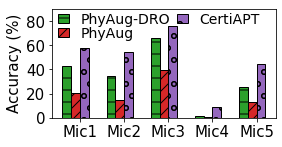

In [59]:
import numpy as np

import matplotlib.pyplot as plt
 
# Data

groups = ['Mic1', 'Mic2', 'Mic3', 'Mic4', 'Mic5']

subgroups = ['PhyAug-DRO', 'PhyAug', 'CertiAPT']

# data = [[75.72, 75.99, 83.49, 36.08, 63.23],
#         [74.9, 75.99, 82.54, 43.11, 61.94],
#         [78.17, 78.85, 85.06, 44.88, 66.44]
#        ]  # Random data for 3 groups and 4 columns each
data = [
        [42.7, 34.99, 65.76, 1.64, 25.78],
        [20.6, 15.14, 39.5, 0.75, 13.17],
        [57.44, 54.57, 75.65, 9.07, 44.54]
       
       ]

data = np.array(data)
bar_width = 0.2

index = np.arange(len(groups))
 
# Hatch patterns for different subgroups

# hatches = ['//', '\\', '|', '-']
 
# Plotting the bars for each subgroup in each group

fig, ax = plt.subplots(figsize=(4,2))

hatch = ["-", "//", 'o']

cc = ['tab:green', 'tab:red', 'tab:purple']

for i in range(len(subgroups)):
#         ax.bar(index + (i)*bar_width, data[i], bar_width, label=subgroups[i], edgecolor='black', hatch=hatch[i], color=cc[i])
        ax.bar(index + i * bar_width, data[i], bar_width, label=subgroups[i], edgecolor='black', hatch=hatch[i], color=cc[i])
 
# Add labels and title

# ax.set_xlabel('Training data', fontsize=15)

ax.set_ylabel('Accuracy (%)', fontsize=15)

# ax.set_title('Bar Graph with 3 Groups and 4 Striped Columns per Group')

ax.set_xticks(index + bar_width * 1.5)  # Adjust position of group labels

ax.set_xticklabels(groups)

ax.legend(fontsize=14, loc=(0.0,0.66), ncol=2, columnspacing=0.5, labelspacing=0,frameon=False,handlelength=0.8)

plt.yticks(np.arange(0, 90, 20), fontsize=15)

plt.xticks(fontsize=15)

plt.ylim(0, 90)

# Display the plot

fig.savefig("asr10.pdf",bbox_inches = 'tight', pad_inches = 0)

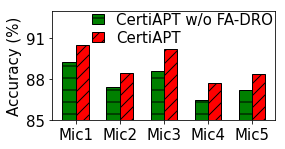

In [8]:
import numpy as np

import matplotlib.pyplot as plt
 
# Data

groups = ['Mic1', 'Mic2', 'Mic3', 'Mic4', 'Mic5']

subgroups = ['CertiAPT w/o FA-DRO', 'CertiAPT']

data = [[89.28, 87.38, 88.62, 86.49, 87.18],

        [90.47, 88.43, 90.21, 87.73, 88.39]

       ]

data = np.array(data)
bar_width = 0.3

index = np.arange(len(groups))
 
# Hatch patterns for different subgroups

# hatches = ['//', '\\', '|', '-']
 
# Plotting the bars for each subgroup in each group

fig, ax = plt.subplots(figsize=(4,2))

hatch = ["-", "//", 'o']

cc = ['green', 'red' ]

for i in range(len(subgroups)):
        ax.bar(index + (i+1)*bar_width, data[i], bar_width, label=subgroups[i], edgecolor='black', hatch=hatch[i], color=cc[i])
 
# Add labels and title

# ax.set_xlabel('Training data', fontsize=15)

ax.set_ylabel('Accuracy (%)', fontsize=15)

# ax.set_title('Bar Graph with 3 Groups and 4 Striped Columns per Group')

ax.set_xticks(index + bar_width * 1.5)  # Adjust position of group labels

ax.set_xticklabels(groups)

ax.legend(fontsize=15, loc=(0.15,0.63), ncol=1, columnspacing=0.5, labelspacing=0.2,frameon=False,handlelength=0.8)

plt.yticks(np.arange(85, 92, 3), fontsize=15)

plt.xticks(fontsize=15)

plt.ylim(85, 93)

# Display the plot



fig.savefig("rob-apt-kws_1.pdf",bbox_inches = 'tight', pad_inches = 0)